In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
df = pd.read_csv(
    "../data/processed/reddit_posts_sentiment.csv"
)

df["timestamp"] = pd.to_datetime(df["timestamp"])

df["month"] = df["timestamp"].dt.strftime("%b")

df.head()

,keyword,title,subreddit,timestamp,post_url,scrape_date,batch_number,source,clean_title,location,skill,role,sentiment,score,month
0,developersindia hiring,How's Infosys for starters 😳,r/IndiaTech,2026-03-10 07:42:32+00:00,https://old.reddit.com/r/IndiaTech/comments/1r...,NaN,NaN,NaN,hows infosys for starters,Unknown,Unknown,Software Engineer,Neutral,0.0,Mar
1,developersindia hiring,Who's hiring? - Monthly Megathread - June 2026,r/developersIndia,2026-06-01 04:32:05+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos hiring monthly megathread june 2026,Unknown,Unknown,Software Engineer,Neutral,0.0,Jun
2,developersindia hiring,Who's hiring? - Monthly Megathread - February ...,r/developersIndia,2026-02-01 04:32:29+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos hiring monthly megathread february 2026,Unknown,Unknown,Software Engineer,Neutral,0.0,Feb
3,developersindia hiring,Who's looking for work? - Monthly Megathread -...,r/developersIndia,2026-06-01 04:30:14+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos looking for work monthly megathread june ...,Unknown,Unknown,Software Engineer,Neutral,0.0,Jun
4,developersindia hiring,Who's hiring? - Monthly Megathread - May 2026,r/developersIndia,2026-05-01 04:32:13+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos hiring monthly megathread may 2026,Unknown,Unknown,Software Engineer,Neutral,0.0,May


# Graph 1 Monthly Hiring Trend

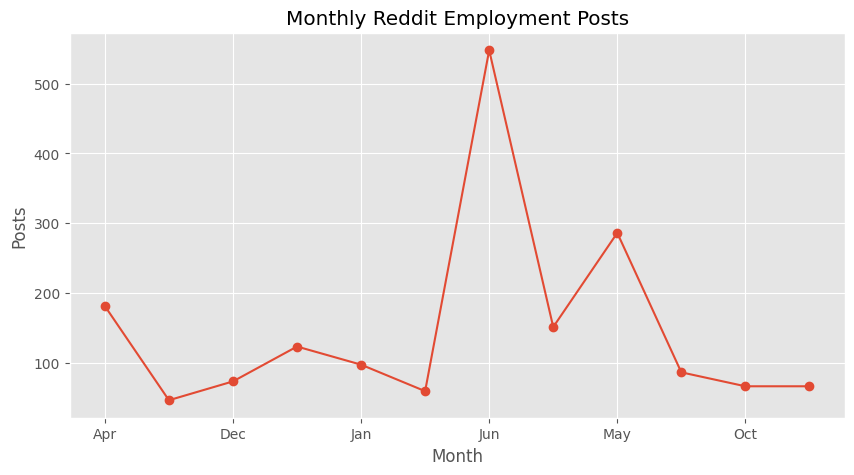

In [3]:
monthly = df.groupby(
    "month"
).size()

monthly.plot(

    kind="line",

    figsize=(10,5),

    marker="o"

)

plt.title("Monthly Reddit Employment Posts")

plt.xlabel("Month")

plt.ylabel("Posts")

plt.show()

# Graph 2 Top 15 Skills

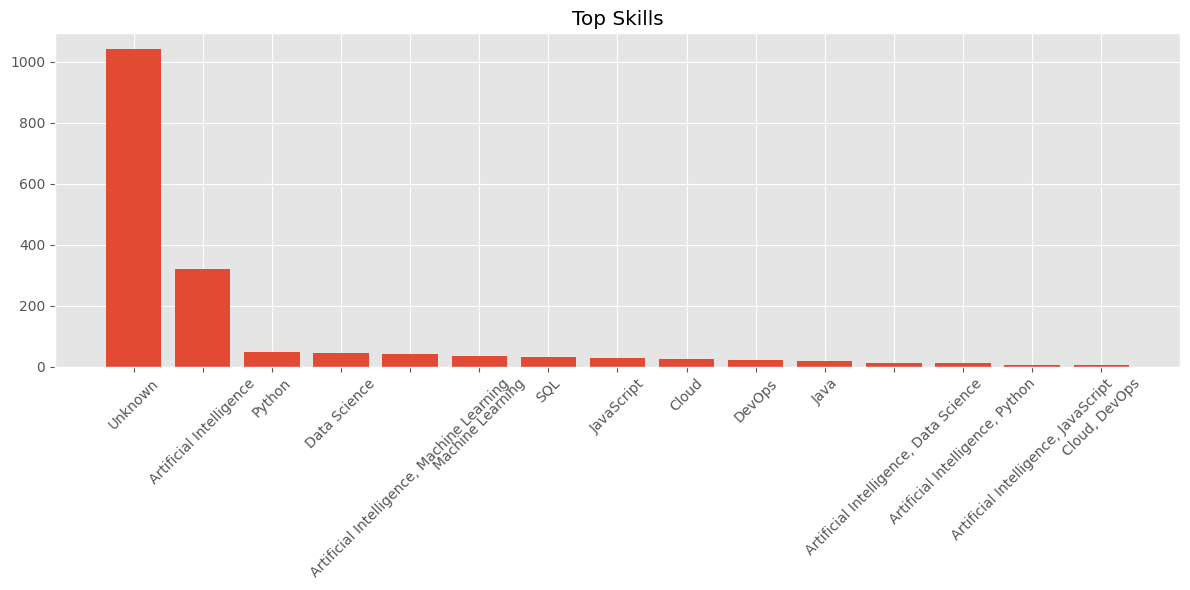

In [4]:
top_skills = (
    df["skill"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,6))

plt.bar(

    top_skills.index,

    top_skills.values

)

plt.xticks(rotation=45)

plt.title("Top Skills")

plt.tight_layout()

plt.show()

# Top Roles

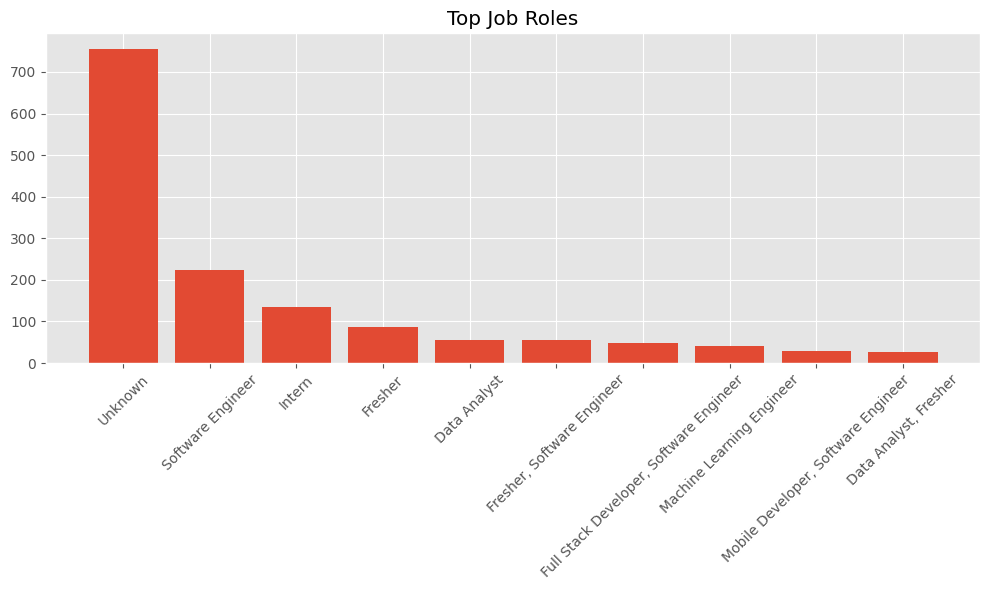

In [5]:
roles = (
    df["role"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

plt.bar(

    roles.index,

    roles.values

)

plt.xticks(rotation=45)

plt.title("Top Job Roles")

plt.tight_layout()

plt.show()

# Top Hiring Cities

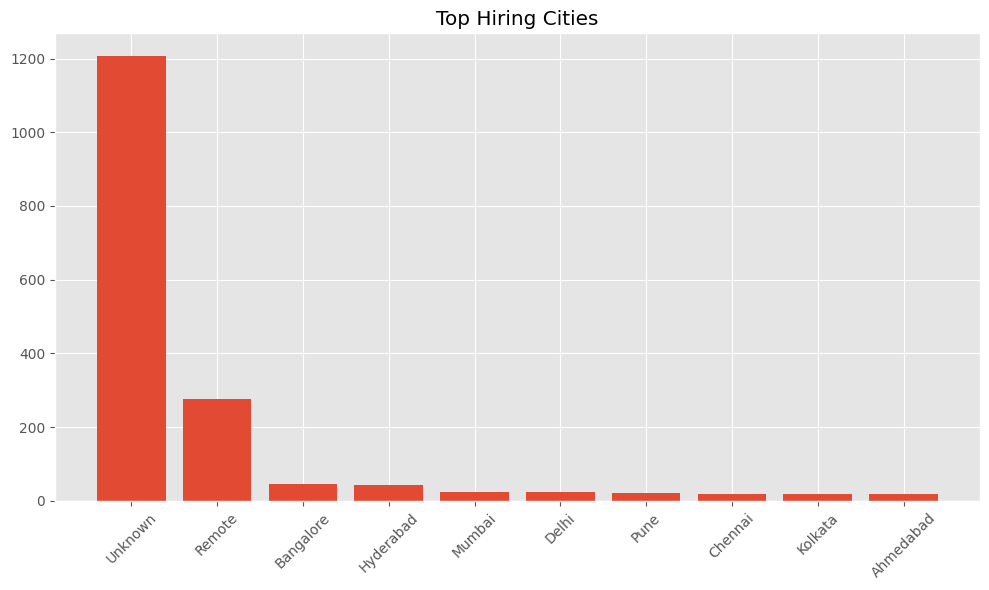

In [6]:
cities = (

    df["location"]

    .value_counts()

    .head(10)

)

plt.figure(figsize=(10,6))

plt.bar(

    cities.index,

    cities.values

)

plt.title("Top Hiring Cities")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# Top Companies

In [8]:
companies = [

    "google",

    "amazon",

    "microsoft",

    "infosys",

    "tcs",

    "accenture",

    "cognizant",

    "wipro",

    "ibm",

    "meta"

]

company_count = {}

titles = df["clean_title"]

for company in companies:

    company_count[company] = (

        titles.str.contains(

            company,

            case=False

        ).sum()

    )

company_df = pd.DataFrame(

    company_count.items(),

    columns=[

        "Company",

        "Posts"

    ]

)

company_df = company_df.sort_values(

    "Posts",

    ascending=False

)

company_df

,Company,Posts
0,google,39
4,tcs,30
6,cognizant,28
3,infosys,28
1,amazon,26
2,microsoft,26
5,accenture,24
9,meta,23
8,ibm,22
7,wipro,20


# AI vs ML vs Python

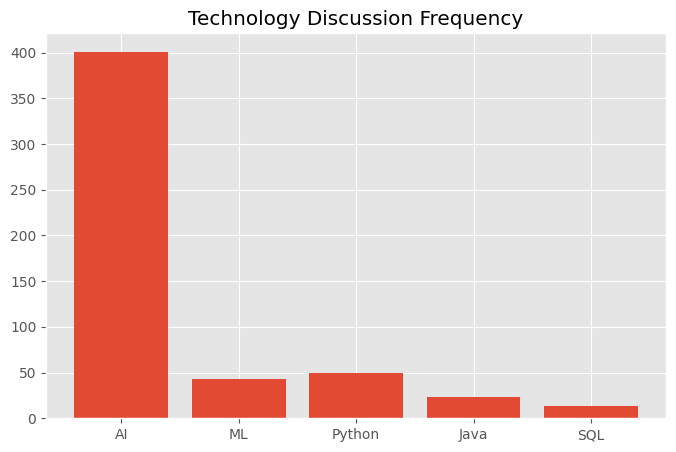

In [9]:
keywords = {

    "AI":"ai",

    "ML":"machine learning",

    "Python":"python",

    "Java":"java",

    "SQL":"sql"

}

counts = {}

for key,value in keywords.items():

    counts[key] = (

        df["clean_title"]

        .str.contains(

            value,

            case=False

        )

        .sum()

    )

plt.figure(figsize=(8,5))

plt.bar(

    counts.keys(),

    counts.values()

)

plt.title(

    "Technology Discussion Frequency"

)

plt.show()

# Internship Trend

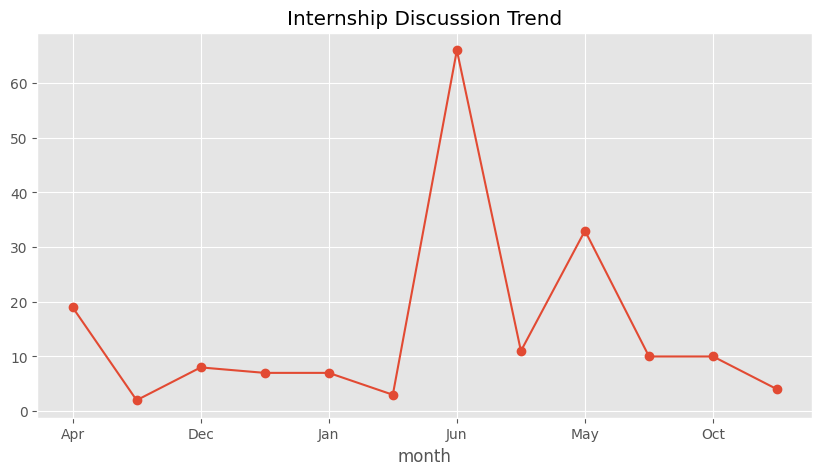

In [10]:
intern = df[

    df["clean_title"]

    .str.contains(

        "intern",

        case=False

    )

]

intern.groupby(

    "month"

).size().plot(

    marker="o",

    figsize=(10,5)

)

plt.title(

    "Internship Discussion Trend"

)

plt.show()

# Role vs Location

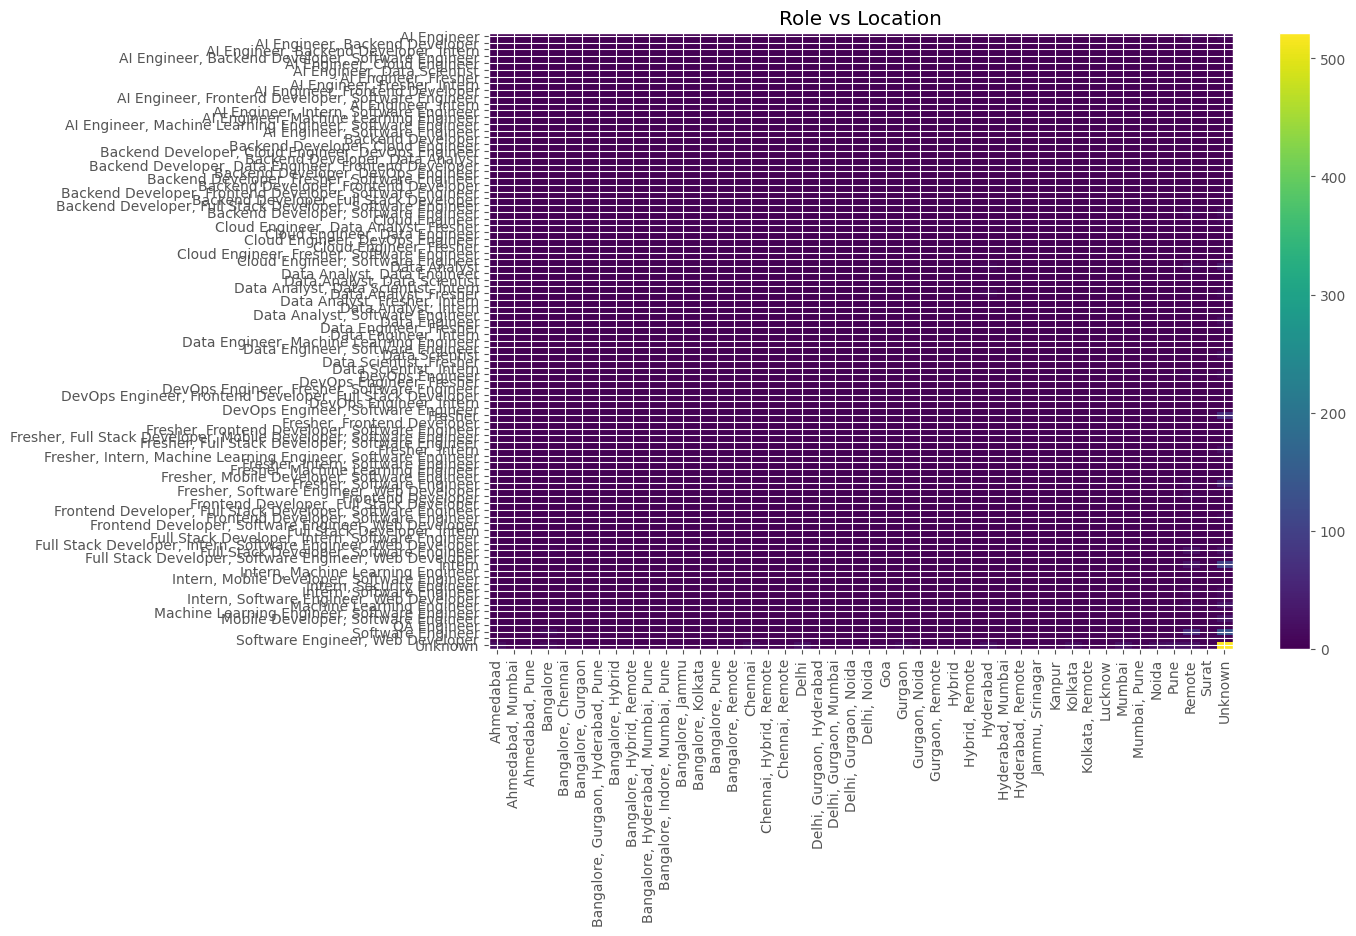

In [11]:
pivot = pd.crosstab(

    df["role"],

    df["location"]

)

plt.figure(figsize=(12,8))

plt.imshow(

    pivot,

    aspect="auto"

)

plt.xticks(

    range(len(pivot.columns)),

    pivot.columns,

    rotation=90

)

plt.yticks(

    range(len(pivot.index)),

    pivot.index

)

plt.colorbar()

plt.title(

    "Role vs Location"

)

plt.show()

In [12]:
df.to_csv(

    "../data/processed/reddit_posts_final.csv",

    index=False

)